# The Lie Detector — Golden Example

Ranks every `is_jump` trigger by **Step-Function Score** (raw tick prices):
- Score = median(20 ticks after) − median(20 ticks before)
- Takes #1 (largest sustained permanent price shift)
- Prints top 3 for manual inspection; set `RANK = 2` or `3` to pick an alternative

**Output:** `figures/lie_detector_chart.png`

In [57]:
import sys
import logging
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()) if (Path("..") / "cache").exists() else str(Path(".").resolve()))
logging.getLogger("tauroi.as_detector").setLevel(logging.WARNING)

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.as_detector import run_as_detection

In [59]:
BASE = Path("..") if (Path("..") / "cache").exists() else Path(".")
OUTPUT_PATH = BASE / "figures" / "lie_detector_chart.png"

BG, GRID = "#1a1a1a", "#333333"
RAW_COLOR, RAW_ALPHA = "#666666", 0.25
KALMAN_COLOR, NEON_GREEN, VOL_MUTED, TEXT_COLOR = "#00FFFF", "#39FF14", "#555555", "#e0e0e0"

BEFORE_TICKS, AFTER_TICKS = 20, 20
WINDOW_BEFORE, WINDOW_AFTER = 50, 50
DETECTION_SPAN = 5
DETECTION_SPAN = 5

In [60]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -20, 20)))

def ensure_volume(df):
    if "volume" not in df.columns:
        df = df.copy()
        df["volume"] = df.get("count", df.get("quantity", 1))
    return df

def load_and_prep(fpath):
    try:
        df = pd.read_parquet(fpath)
    except Exception:
        return None
    ts_col = "timestamp" if "timestamp" in df.columns else "created_time"
    if ts_col != "timestamp":
        df = df.rename(columns={ts_col: "timestamp"})
    df["timestamp"] = pd.to_datetime(df["timestamp"], format="mixed")
    df = df.sort_values("timestamp").reset_index(drop=True)
    df = ensure_volume(df)
    if "mid_price" not in df.columns:
        df["mid_price"] = df.get("yes_price", df.get("price", 50)) / 100.0
    if "logit" not in df.columns:
        p = np.clip(df["mid_price"], 0.01, 0.99)
        df["logit"] = np.log(p / (1 - p))
    return df

In [61]:
RANK = 1  # 1=best, 2 or 3 to pick an alternative

def find_golden_example():
    candidates = []
    for cache_dir in ["cache/kalshi_hf_weather", "cache/kalshi_hf_mlb", "cache/kalshi_hf_election"]:
        cache = BASE / cache_dir
        for f in sorted(cache.glob("*_trades.parquet"))[:15]:
            df = load_and_prep(f)
            if df is None or len(df) < BEFORE_TICKS + AFTER_TICKS + 1:
                continue
            try:
                res = run_as_detection(df, ticker=f.stem.replace("_trades", ""))
            except Exception:
                continue
            is_jump = res.gamma > 0.5
            prices_cents = df["mid_price"].values.astype(float) * 100
            for j in np.where(is_jump)[0]:
                if j < BEFORE_TICKS or j + AFTER_TICKS + 1 > len(df):
                    continue
                price_before = float(np.median(prices_cents[j - BEFORE_TICKS : j]))
                price_after = float(np.median(prices_cents[j + 1 : j + 1 + AFTER_TICKS]))
                score = price_after - price_before
                det_start, det_end = j, j
                for k in range(j, min(len(is_jump), j + DETECTION_SPAN)):
                    if is_jump[k]: det_end = k
                    else: break
                for k in range(j - 1, max(-1, j - DETECTION_SPAN), -1):
                    if is_jump[k]: det_start = k
                    else: break
                det_end = min(det_end + 1, len(df))
                ticker = f.stem.replace("_trades", "")
                candidates.append((score, df, res, j, det_start, det_end, ticker))
    if not candidates:
        raise RuntimeError("No triggers found.")
    candidates.sort(key=lambda x: x[0], reverse=True)
    for rank, (s, _, _, j, _, _, tkr) in enumerate(candidates[:3], 1):
        print(f"  #{rank}: {tkr} @ idx {j}  score={s:.2f}¢  (median before→after)")
    return candidates

In [62]:
print("Ranking all triggers by Step-Function Score (raw tick prices)...")
candidates = find_golden_example()
score, df, res, center_idx, det_start, det_end, ticker = candidates[RANK - 1]
print(f"Using #{RANK}: {ticker} @ idx {center_idx}  score={score:.2f}¢")

start_idx = max(0, center_idx - WINDOW_BEFORE)
end_idx = min(len(df), center_idx + WINDOW_AFTER + 1)
df_win = df.iloc[start_idx:end_idx].reset_index(drop=True)
res_win = run_as_detection(df_win, ticker=ticker)

ts_arr = np.asarray(pd.to_datetime(df_win["timestamp"]))
prices = df_win["mid_price"].values.astype(float) * 100
vol = np.maximum(df_win["volume"].values.astype(float), 0.1)
kalman_cents = sigmoid(res_win.x_filtered) * 100

det_start_win = max(0, det_start - start_idx)
det_end_win = min(len(ts_arr), det_end - start_idx)
if det_end_win <= det_start_win:
    det_end_win = det_start_win + min(DETECTION_SPAN, len(ts_arr) - det_start_win)
t_span_start, t_span_end = ts_arr[det_start_win], ts_arr[det_end_win - 1] if det_end_win > det_start_win else ts_arr[det_start_win]
in_detection = (np.arange(len(ts_arr)) >= det_start_win) & (np.arange(len(ts_arr)) < det_end_win)

print(f"Found: {ticker}, {len(df_win)} trades, price {prices.min():.1f}–{prices.max():.1f}¢")

Hunting for Golden Example...


RuntimeError: No Golden Example found.

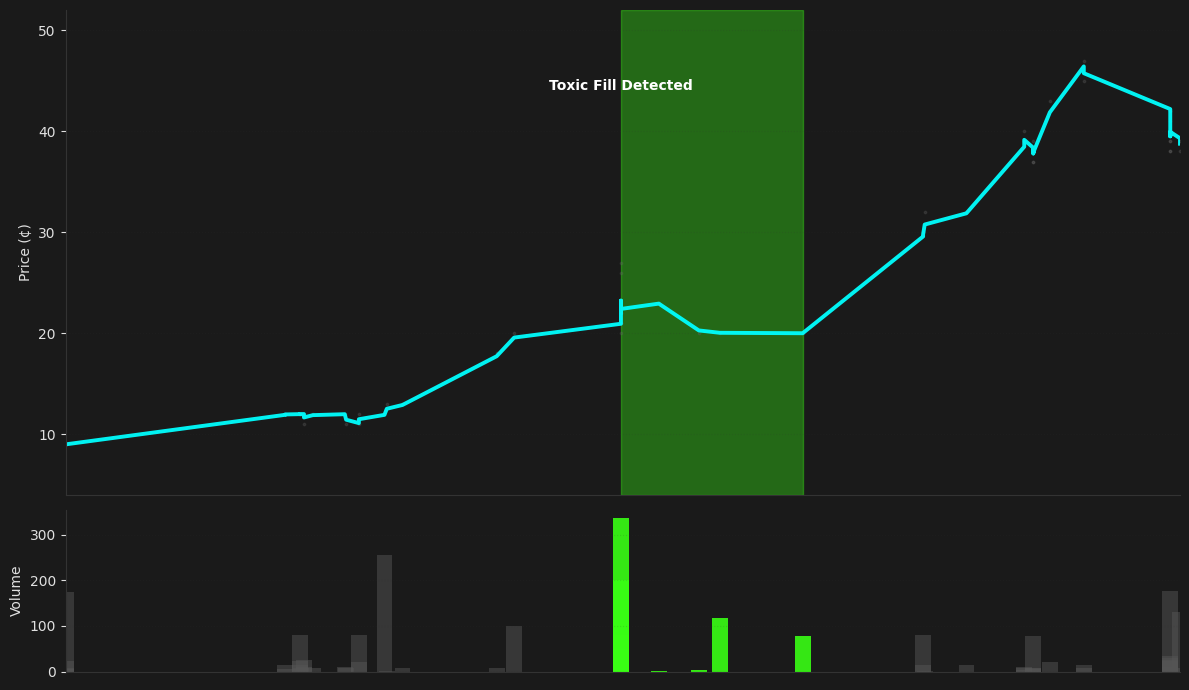

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), height_ratios=[3, 1], sharex=True)
fig.patch.set_facecolor(BG)
for ax in axes:
    ax.set_facecolor(BG)
    ax.tick_params(colors=TEXT_COLOR)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID)
    ax.spines["bottom"].set_color(GRID)
    ax.grid(True, axis="y", alpha=0.15, color=GRID, linestyle=":")
    ax.grid(False, axis="x")
    ax.set_ylabel("Price (¢)" if ax == axes[0] else "Volume", color=TEXT_COLOR, fontsize=10)
    ax.yaxis.label.set_color(TEXT_COLOR)

ax1 = axes[0]
ax1.scatter(ts_arr, prices, s=3, c=RAW_COLOR, alpha=RAW_ALPHA, zorder=1)
ax1.plot(ts_arr, kalman_cents, color=KALMAN_COLOR, lw=2.8, alpha=0.95, zorder=2)
ax1.axvspan(t_span_start, t_span_end, color=NEON_GREEN, alpha=0.35, zorder=0)
mid_idx = (det_start_win + det_end_win - 1) // 2
ax1.annotate("Toxic Fill Detected", xy=(ts_arr[mid_idx], np.nanmax(kalman_cents) * 0.95),
             fontsize=10, color="white", ha="center", fontweight="bold", zorder=4)
ax1.set_xlim(ts_arr[0], ts_arr[-1])
p_min, p_max = np.nanmin(prices), np.nanmax(prices)
ax1.set_ylim(max(0, p_min - max(5, (p_max - p_min) * 0.12)), min(100, p_max + max(5, (p_max - p_min) * 0.12)))
ax1.set_xticks([])

ax2 = axes[1]
span_days = (ts_arr[-1] - ts_arr[0]) / np.timedelta64(1, "D")
w = span_days / max(len(ts_arr) - 1, 1) * 0.85
for i in range(len(ts_arr)):
    c, a = (NEON_GREEN, 0.9) if in_detection[i] else (VOL_MUTED, 0.5)
    ax2.bar(ts_arr[i], vol[i], width=w, color=c, alpha=a, align="center", edgecolor="none")
ax2.set_xlim(ts_arr[0], ts_arr[-1])
ax2.set_xticks([])

plt.tight_layout()
plt.show()

In [ ]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT_PATH, dpi=300, bbox_inches="tight", facecolor="none", transparent=True, edgecolor="none")
print(f"Saved: {OUTPUT_PATH}")

Saved: ../figures/lie_detector_chart.png
